# Squirmers in a tube with the Boundary Element Method: a step-by-step tutorial

This notebook walks through the whole project, from the simplest possible test to swimmer trajectories. Every step runs the C++ solver (`build/squirmer_bem`) through a small input file, then loads its CSV output and plots it here.

| Step | Problem | What it verifies |
|---|---|---|
| **1** | Pressure-driven flow in an empty tube | The BEM machinery: recovers Poiseuille flow from a pressure drop alone |
| **2a** | Squirmer in unbounded fluid | The swimmer model: speed $2B_1/3$ and Blake's exact flow field |
| **2b** | Squirmer inside the tube | Confinement: drag vs. Haberman–Sayre, flow fields, off-axis drift and rotation |
| **3** | Trajectories | Time integration: wavy, crashing and wall-following swimmers |

**Prerequisites:** a C++17 compiler, OpenBLAS, and Python with `numpy` and `matplotlib`. The full theory, with every equation, is in `README.md`; here we keep only what is needed at each step.

**Units used everywhere:** squirmer radius $a = 1$, viscosity $\mu = 1$, squirming amplitude $B_1 = 1$. Velocities are therefore in units of $B_1$, and times in units of $a/B_1$. The free-space swimming speed is $U_0 = 2B_1/3$.

## 0. Setup

The cell below finds the repository, builds the solver if needed, and defines two helpers:

* `run(input_file, **overrides)` runs the solver. Keyword arguments override values in the input file, exactly like `key=value` on the command line.
* `load(path)` reads a CSV written by the solver. Comment lines start with `#`, and the header gives the column names.

In [1]:
import subprocess, sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BIN = REPO / "build" / "squirmer_bem"
OUT = "outputs/tutorial"              # all results of this notebook go here
sys.path.insert(0, str(REPO / "tests"))  # reuse the plotting functions of the tests

if not BIN.exists():
    print("building the solver ...")
    subprocess.run(["make", "-C", str(REPO), "build/squirmer_bem"], check=True)
print("solver:", BIN)

def run(input_file, **overrides):
    # Run the C++ solver from the repository root and print its log.
    cmd = [str(BIN), input_file] + [f"{k}={v}" for k, v in overrides.items()]
    print("$", " ".join(cmd[1:]))
    t = time.time()
    r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
    print(r.stdout.strip())
    if r.returncode:
        raise RuntimeError(r.stderr)
    print(f"[{time.time() - t:.1f} s]")

def load(path):
    # Read a solver CSV (skip '# ...' lines, first remaining line = header).
    with open(REPO / path) as fh:
        lines = [ln for ln in fh if not ln.startswith("#")]
    return np.genfromtxt(lines, delimiter=",", names=True)

U0 = 2 / 3

solver: /home/claude/squirmer-bem/build/squirmer_bem


### A 60-second summary of the method

At the scale of a microswimmer, inertia is negligible (Reynolds number $\sim 10^{-4}$), so the fluid obeys the **Stokes equations**:

$$ -\nabla p + \mu \nabla^2 \mathbf{u} = 0, \qquad \nabla\cdot\mathbf{u} = 0 .$$

They are linear, and their fundamental solution is known: the **Stokeslet** $G_{ij}(\mathbf r) = \delta_{ij}/r + r_i r_j/r^3$, the flow created by a point force. Because of this, the velocity anywhere in the fluid can be written using only quantities **on the boundaries**: the velocity $\mathbf u$ and the traction $\mathbf f = \boldsymbol\sigma\cdot\mathbf m$ exerted on the boundary.

$$ u_j(\mathbf x_0) = \frac{1}{8\pi\mu}\int_S f_i\, G_{ij}\, dS \;-\; \frac{1}{8\pi}\int_S u_i\, T_{ijk}\, m_k\, dS ,$$

where $T_{ijk} = -6 r_i r_j r_k / r^5$ is the **stresslet** and $\mathbf m$ is the normal pointing out of the fluid.

Placing $\mathbf x_0$ on the boundary itself turns this into an equation that connects $\mathbf u$ and $\mathbf f$ on $S$. This is the **boundary integral equation**. The **boundary element method (BEM)** then:

1. covers the surfaces with flat triangles ("panels");
2. assumes $\mathbf u$ and $\mathbf f$ are constant on each panel;
3. enforces the equation at every panel centre, giving a dense linear system.

Only surfaces are meshed, never the fluid volume. That is what makes BEM efficient for this problem.

## Step 1: Pressure-driven flow in an empty tube

Before adding a swimmer, we check that the machinery works on a problem with a known answer. Take a tube of radius $R$ and length $L$. We impose **only a pressure difference** between the ends, not a velocity profile:

* wall: no slip, $\mathbf u = 0$;
* inlet ($z=0$) and outlet ($z=L$): normal traction $= \mp p$, with zero tangential velocity.

If the solver is right, the parabolic Hagen–Poiseuille flow must come out of the calculation:

$$ u_z(r) = \frac{G}{4\mu}\,(R^2 - r^2), \qquad G = \frac{p_\text{in} - p_\text{out}}{L}, \qquad Q = \frac{\pi R^4 G}{8\mu}. $$

Here is the input file:

In [2]:
print((REPO / "inputs/duct_flow.in").read_text())

# ---------------------------------------------------------------------------
# Stage 1: pressure-driven (Poiseuille) flow in a tube, no swimmer
#   run:  ./build/squirmer_bem inputs/duct_flow.in
# ---------------------------------------------------------------------------
mode       = duct
output_dir = outputs/duct_flow

# geometry (tube from z = 0 to z = L)
R   = 1.0
L   = 4.0
mu  = 1.0

# mesh: panels around the circumference, along the axis, rings on each cap
n_theta = 24
n_z     = 24
n_r     = 6

# pressure drops to solve (the matrix is factorised once; each is a new RHS)
dP_list   = 0.5 1 2 4
p_out     = 0.0
dP_detail = 1.0      # pressure drop used for panels.csv and profile.csv
n_profile = 20       # interior points per radial line at z = L/2



In [3]:
run("inputs/duct_flow.in", output_dir=f"{OUT}/duct")

$ inputs/duct_flow.in output_dir=outputs/tutorial/duct


duct flow: 1680 panels, 5040 unknowns, assembled + factorised in 2.0 s
  dP = 0.5    Q = 0.048911   exact 0.049087   rel. error 3.59e-03
  dP = 1      Q = 0.097822   exact 0.098175   rel. error 3.59e-03
  dP = 2      Q = 0.195645   exact 0.196350   rel. error 3.59e-03
  dP = 4      Q = 0.391290   exact 0.392699   rel. error 3.59e-03
wrote outputs/tutorial/duct/{flow_rate,panels,profile}.csv  (2.1 s)
[2.1 s]


The solver wrote three files:

* `flow_rate.csv`: the flow rate for each pressure drop;
* `profile.csv`: the velocity at points inside the tube at mid-length (computed from the boundary solution with the integral formula above);
* `panels.csv`: $\mathbf u$ and $\mathbf f$ on every panel.

Let's compare them with the exact solution.

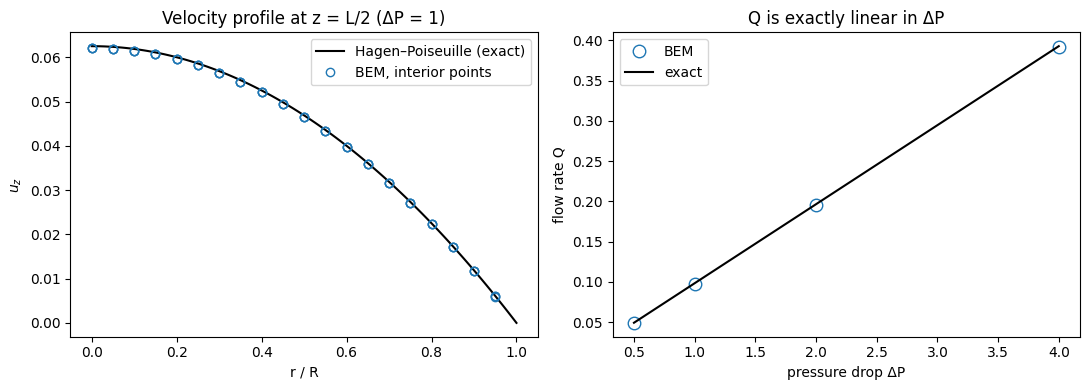

relative error in Q: [0.00358883 0.00358883 0.00358883 0.00358883]


In [4]:
R, L = 1.0, 4.0
prof = load(f"{OUT}/duct/profile.csv")
fq = load(f"{OUT}/duct/flow_rate.csv")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
r = np.linspace(0, 1, 100)
ax[0].plot(r, (1.0 / L) * (R**2 - r**2) / 4, "k-", label="Hagen–Poiseuille (exact)")
ax[0].plot(prof["r"], prof["uz"], "o", mfc="none", label="BEM, interior points")
ax[0].set(xlabel="r / R", ylabel="$u_z$", title="Velocity profile at z = L/2 (ΔP = 1)")
ax[0].legend()
ax[1].plot(fq["dP"], fq["Q"], "o", ms=9, mfc="none", label="BEM")
ax[1].plot(fq["dP"], fq["Q_exact"], "k-", label="exact")
ax[1].set(xlabel="pressure drop ΔP", ylabel="flow rate Q", title="Q is exactly linear in ΔP")
ax[1].legend()
plt.tight_layout(); plt.show()
print("relative error in Q:", fq["rel_err"])

**What to notice**

* The parabola emerges from a pressure drop alone. The solver never imposed it.
* The relative error in $Q$ is identical for every $\Delta P$. Stokes flow is linear, so the solver factorises the matrix once and treats each pressure drop as a new right-hand side.
* The ~0.4 % error comes mostly from representing a round tube with flat panels. The mesh generator already compensates for the leading part of this: it places the polygon vertices slightly outside $R$ so that the faceted cross-section has the correct **area**. Without that correction, the error on this mesh is 2.6 % (see README, "Discretisation").

**Try it:** refine the mesh and watch the error decrease.

In [5]:
rows = []
for nth, nz, nr in [(12, 12, 3), (16, 16, 4), (24, 24, 6)]:
    run("inputs/duct_flow.in", output_dir=f"{OUT}/duct_conv", n_theta=nth, n_z=nz, n_r=nr, dP_list=1)
    q = load(f"{OUT}/duct_conv/flow_rate.csv")
    rows.append((nth, float(q["rel_err"])))
for nth, e in rows:
    print(f"n_theta = {nth:2d}:  relative error in Q = {e:.2e}")

$ inputs/duct_flow.in output_dir=outputs/tutorial/duct_conv n_theta=12 n_z=12 n_r=3 dP_list=1
duct flow: 408 panels, 1224 unknowns, assembled + factorised in 0.1 s
  dP = 1      Q = 0.097239   exact 0.098175   rel. error 9.53e-03
wrote outputs/tutorial/duct_conv/{flow_rate,panels,profile}.csv  (0.1 s)
[0.1 s]
$ inputs/duct_flow.in output_dir=outputs/tutorial/duct_conv n_theta=16 n_z=16 n_r=4 dP_list=1


duct flow: 736 panels, 2208 unknowns, assembled + factorised in 0.2 s
  dP = 1      Q = 0.097544   exact 0.098175   rel. error 6.42e-03
wrote outputs/tutorial/duct_conv/{flow_rate,panels,profile}.csv  (0.2 s)
[0.2 s]
$ inputs/duct_flow.in output_dir=outputs/tutorial/duct_conv n_theta=24 n_z=24 n_r=6 dP_list=1


duct flow: 1680 panels, 5040 unknowns, assembled + factorised in 1.8 s
  dP = 1      Q = 0.097822   exact 0.098175   rel. error 3.59e-03
wrote outputs/tutorial/duct_conv/{flow_rate,panels,profile}.csv  (1.8 s)
[1.9 s]
n_theta = 12:  relative error in Q = 9.53e-03
n_theta = 16:  relative error in Q = 6.42e-03
n_theta = 24:  relative error in Q = 3.59e-03


## Step 2a: A squirmer in unbounded fluid

The **squirmer** (Lighthill 1952, Blake 1971) is a sphere of radius $a$ that swims by imposing a tangential slip velocity on its own surface, like a ciliated microorganism:

$$ \mathbf u_s = \left(B_1 \sin\theta + B_2 \sin\theta\cos\theta\right)\mathbf e_\theta , $$

where $\theta$ is measured from the swimming direction $\mathbf e$. The ratio $\alpha = B_2/B_1$ sets the swimmer type:

* $\alpha < 0$: **pusher** (e.g. bacteria), pushes fluid out at the front and back;
* $\alpha = 0$: **neutral** squirmer;
* $\alpha > 0$: **puller** (e.g. algae), pulls fluid in at the front and back.

The squirmer's velocity $\mathbf U$ and rotation $\boldsymbol\Omega$ are **unknowns**. Its surface moves as $\mathbf u = \mathbf U + \boldsymbol\Omega\times(\mathbf x-\mathbf x_c) + \mathbf u_s$. The six extra equations that close the system come from requiring the swimmer to be **force-free and torque-free**: nothing pushes it except the fluid.

In unbounded fluid the exact answer is known:

* $\mathbf U = \tfrac{2}{3}B_1\,\mathbf e$, independent of $B_2$;
* the flow field is (Blake 1971, lab frame):

$$ u_r = \frac{2B_1}{3}\frac{a^3}{r^3}\cos\theta + B_2\left(\frac{a^4}{r^4}-\frac{a^2}{r^2}\right)P_2(\cos\theta), \qquad u_\theta = \frac{B_1}{3}\frac{a^3}{r^3}\sin\theta + B_2\frac{a^4}{r^4}\sin\theta\cos\theta. $$

The solver always computes the two **modes** ($B_1=1, B_2=0$) and ($B_1=0, B_2=1$). By linearity, any squirmer is $\mathbf U = \mathbf U_{B_1} + \alpha\,\mathbf U_{B_2}$. Setting `a_over_R = 0` removes the tube.

In [6]:
for lev in (2, 3):
    run("inputs/squirmer_kinematics.in", output_dir=f"{OUT}/free_L{lev}",
        a_over_R=0, beta=0, sphere_level=lev)
    k = load(f"{OUT}/free_L{lev}/kinematics.csv")
    print(f"sphere level {lev} ({20 * 4**lev} panels): U/U0 = {float(k['UB1z']) / U0:.5f}, "
          f"drag/6pi mu a U = {float(k['drag_K']):.5f}, U from B2 mode = {float(k['UB2z']):.1e}\n")

$ inputs/squirmer_kinematics.in output_dir=outputs/tutorial/free_L2 a_over_R=0 beta=0 sphere_level=2
a/R=0.00 beta=0.00: U_B1/U0=(-0.0000,+0.0000,0.9958) Om_B1=(-0.0000,-0.0000,+0.0000) U_B2/U0=(+0.0000,+0.0000,-0.0000) K=0.9984 [0.1s]
[0.1 s]
sphere level 2 (320 panels): U/U0 = 0.99579, drag/6pi mu a U = 0.99837, U from B2 mode = -1.9e-18

$ inputs/squirmer_kinematics.in output_dir=outputs/tutorial/free_L3 a_over_R=0 beta=0 sphere_level=3


a/R=0.00 beta=0.00: U_B1/U0=(+0.0000,+0.0000,0.9990) Om_B1=(+0.0000,-0.0000,-0.0000) U_B2/U0=(+0.0000,-0.0000,-0.0000) K=0.9996 [2.5s]
[2.5 s]
sphere level 3 (1280 panels): U/U0 = 0.99899, drag/6pi mu a U = 0.99956, U from B2 mode = -9.9e-17



Both the swimming speed and the Stokes drag $6\pi\mu a U$ come out within 0.1 % on the fine sphere (level 3). The $B_2$ mode produces no motion, as the theory says.

Now the **flow field**. The `field` mode evaluates the velocity on a grid in the $x$–$z$ plane. We compare a pusher ($\alpha = -3$) with Blake's formula:

$ inputs/squirmer_field.in output_dir=outputs/tutorial/field_free a_over_R=0 x_extent=4 z_extent=4 sphere_level=3


field: 1356 points x 2 modes, U_B1 = 0.66599  (2.0 s)
[2.0 s]


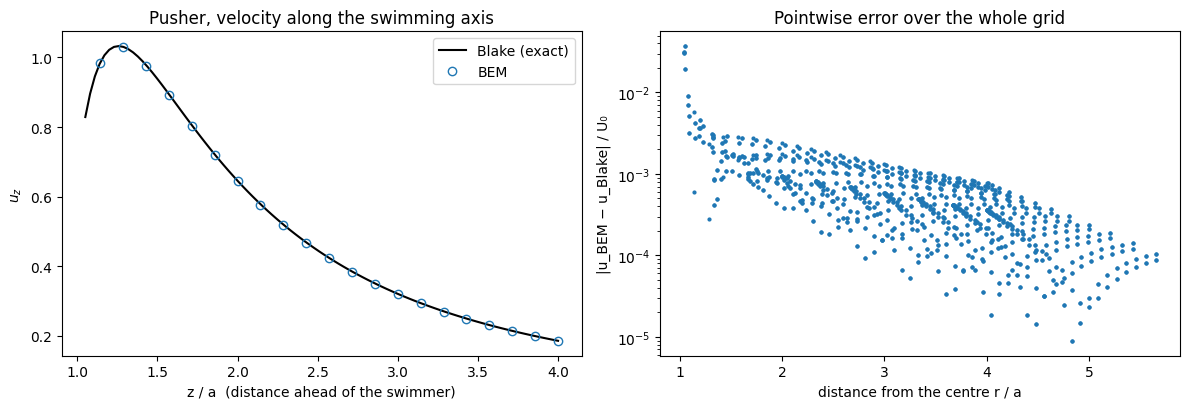

In [7]:
run("inputs/squirmer_field.in", output_dir=f"{OUT}/field_free",
    a_over_R=0, x_extent=4, z_extent=4, sphere_level=3)

def blake(x, z, B1, B2):
    # Blake's squirmer flow (lab frame, a = 1, swimming along +z): returns (u_x, u_z).
    r = np.hypot(x, z); c = z / r; s = x / r
    ur = 2/3 * B1 * c / r**3 + (r**-4 - r**-2) * B2 * (3*c**2 - 1) / 2
    ut = B1/3 * s / r**3 + B2 * s * c / r**4
    return ur * s + ut * c, ur * c - ut * s     # e_r = (s, c), e_theta = (c, -s)

alpha = -3
f1, f2 = load(f"{OUT}/field_free/field_B1.csv"), load(f"{OUT}/field_free/field_B2.csv")
x, z = f1["x"], f1["z"]
ux, uz = f1["ux"] + alpha * f2["ux"], f1["uz"] + alpha * f2["uz"]
bx, bz = blake(x, z, 1, alpha)
r = np.hypot(x, z)
err = np.hypot(ux - bx, uz - bz) / U0

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
on_axis = (np.abs(x) < 1e-9) & (z > 1.05)
zz = np.linspace(1.05, 4, 100)
ax[0].plot(zz, blake(0 * zz, zz, 1, alpha)[1], "k-", label="Blake (exact)")
ax[0].plot(z[on_axis], uz[on_axis], "o", mfc="none", label="BEM")
ax[0].set(xlabel="z / a  (distance ahead of the swimmer)", ylabel="$u_z$",
          title="Pusher, velocity along the swimming axis")
ax[0].legend()
ok = ~np.isnan(err)
ax[1].semilogy(r[ok], err[ok], ".", ms=4)
ax[1].set(xlabel="distance from the centre r / a", ylabel="|u_BEM − u_Blake| / U₀",
          title="Pointwise error over the whole grid")
plt.tight_layout(); plt.show()

The error is largest right next to the sphere, where the flat panels are only an approximation of the curved surface, and it falls off quickly with distance. Near a boundary, the integrals are nearly singular; the solver refines its quadrature automatically, but a point closer than about one panel size to the surface is still less accurate. This is a general property of BEM worth remembering.

## Step 2b: The squirmer inside the tube

Now put the squirmer in a tube of radius $R$. The confinement is $a/R$, and the offset from the axis is $\beta = b/(R-a)$, so that $\beta = 1$ means touching the wall. As in Zhu, Lauga & Brandt (2013), the tube is **closed** with $\mathbf u = 0$ on both ends. With a length of $4R$, the ends are far enough away that they don't matter: the flow disturbance decays exponentially along a tube.

### Validation first: a towed rigid sphere

With the slip switched off and the sphere dragged along the axis at speed $U$, the drag correction $K = F / 6\pi\mu a U$ is known (Haberman & Sayre 1958, accurate for $a/R \lesssim 0.4$). The `kinematics` mode computes this `drag_K` whenever the sphere is on the axis.

In [8]:
run("inputs/squirmer_kinematics.in", output_dir=f"{OUT}/axis",
    a_over_R="0.1 0.2 0.3 0.4", beta=0, n_theta=24, sphere_level=2)
k = load(f"{OUT}/axis/kinematics.csv")
lam = k["a_over_R"]
HS = (1 - 0.75857*lam**5) / (1 - 2.1050*lam + 2.0865*lam**3 - 1.7068*lam**5 + 0.72603*lam**6)
print(" a/R    K (BEM)   K (Haberman-Sayre)   ratio    squirmer U/U0")
for l, kb, kh, u in zip(lam, k["drag_K"], HS, k["UB1z"] / U0):
    print(f"{l:4.1f}   {kb:7.4f}   {kh:7.4f}              {kb/kh:.4f}   {u:.4f}")

$ inputs/squirmer_kinematics.in output_dir=outputs/tutorial/axis a_over_R=0.1 0.2 0.3 0.4 beta=0 n_theta=24 sphere_level=2


a/R=0.10 beta=0.00: U_B1/U0=(-0.0000,-0.0000,0.9937) Om_B1=(-0.0000,-0.0000,-0.0000) U_B2/U0=(-0.0000,-0.0000,+0.0000) K=1.2609 [0.9s]
a/R=0.20 beta=0.00: U_B1/U0=(+0.0000,+0.0000,0.9798) Om_B1=(-0.0000,+0.0000,-0.0000) U_B2/U0=(+0.0000,+0.0000,-0.0000) K=1.6758 [0.8s]
a/R=0.30 beta=0.00: U_B1/U0=(+0.0000,+0.0000,0.9442) Om_B1=(-0.0000,-0.0000,-0.0000) U_B2/U0=(-0.0000,-0.0000,+0.0000) K=2.3641 [0.9s]
a/R=0.40 beta=0.00: U_B1/U0=(-0.0000,-0.0000,0.8810) Om_B1=(-0.0000,-0.0000,-0.0000) U_B2/U0=(+0.0000,+0.0000,+0.0000) K=3.5803 [1.0s]
[7.8 s]
 a/R    K (BEM)   K (Haberman-Sayre)   ratio    squirmer U/U0
 0.1    1.2609    1.2633              0.9981   0.9937
 0.2    1.6758    1.6797              0.9977   0.9798
 0.3    2.3641    2.3697              0.9976   0.9442
 0.4    3.5803    3.5816              0.9996   0.8810


The drag agrees to within about 0.3 %, and the swimmer slows down as the tube narrows. On the axis, the $B_2$ mode still produces no motion, so pushers, pullers and neutral squirmers all swim at the same speed there.

### Flow fields

The flow in a tube is very different from free space. In free space, the forward flow decays slowly with distance. In a closed tube, fluid pushed forward must come back along the walls, creating recirculating vortices. Here we compute both modes once and combine them for three swimmer types.

$ inputs/squirmer_field.in output_dir=outputs/tutorial/field_tube


field: 1378 points x 2 modes, U_B1 = 0.63139  (8.1 s)
[8.2 s]


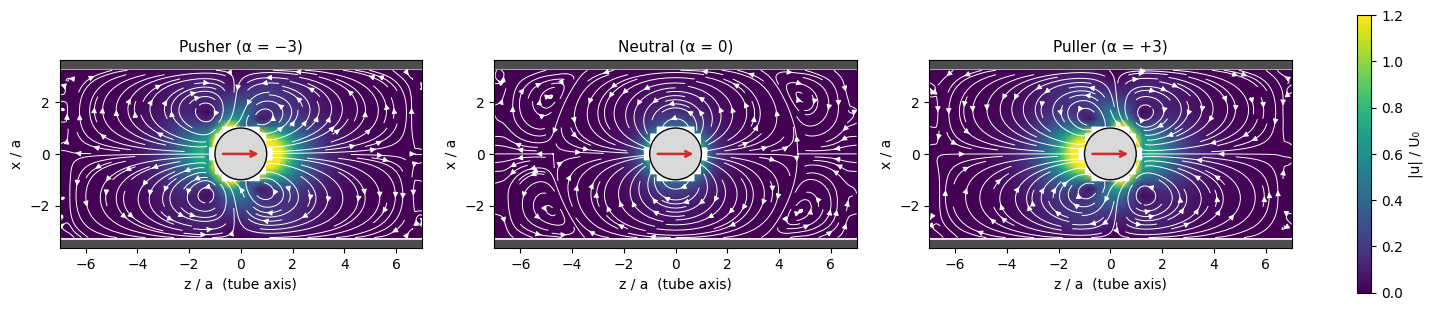

In [9]:
run("inputs/squirmer_field.in", output_dir=f"{OUT}/field_tube")   # a/R = 0.3 on the axis
import plot_squirmer

f1, f2 = load(f"{OUT}/field_tube/field_B1.csv"), load(f"{OUT}/field_tube/field_B2.csv")
xs, zs = np.unique(f1["x"]), np.unique(f1["z"])
shape = (len(xs), len(zs))
R = 1 / 0.3
fig, axs = plt.subplots(1, 3, figsize=(17, 3.6))
for axx, (alpha, name) in zip(axs, [(-3, "Pusher (α = −3)"), (0, "Neutral (α = 0)"), (3, "Puller (α = +3)")]):
    ux = (f1["ux"] + alpha * f2["ux"]).reshape(shape)
    uz = (f1["uz"] + alpha * f2["uz"]).reshape(shape)
    pc = plot_squirmer.draw_field(axx, xs, zs, R, ux, uz, name)
fig.colorbar(pc, ax=axs, fraction=0.015, label="|u| / U₀")
plt.show()

### Off the axis: drift and rotation

When the squirmer is closer to one wall (here the wall on the $+x$ side), symmetry is broken and two new effects appear:

* the $B_1$ mode **rotates** the swimmer away from the nearest wall ($\Omega_y < 0$) but causes no sideways drift;
* the $B_2$ mode causes a **sideways drift**: pullers ($\alpha > 0$) move away from the wall and pushers move toward it. It causes no rotation.

This is exactly what Zhu, Lauga & Brandt (2013) report.

$ inputs/squirmer_kinematics.in output_dir=outputs/tutorial/offaxis beta=0 0.2 0.4 0.6 0.75 n_theta=24 sphere_level=2 towed_drag=0


a/R=0.30 beta=0.00: U_B1/U0=(+0.0000,+0.0000,0.9442) Om_B1=(-0.0000,-0.0000,-0.0000) U_B2/U0=(-0.0000,-0.0000,+0.0000) K=nan [1.0s]
a/R=0.30 beta=0.20: U_B1/U0=(-0.0000,+0.0000,0.9438) Om_B1=(+0.0000,-0.0032,-0.0000) U_B2/U0=(-0.0202,-0.0000,+0.0000) K=nan [1.0s]
a/R=0.30 beta=0.40: U_B1/U0=(-0.0000,+0.0000,0.9419) Om_B1=(+0.0000,-0.0076,-0.0000) U_B2/U0=(-0.0425,-0.0000,+0.0000) K=nan [1.0s]
a/R=0.30 beta=0.60: U_B1/U0=(-0.0000,+0.0000,0.9366) Om_B1=(+0.0000,-0.0167,-0.0000) U_B2/U0=(-0.0695,-0.0000,+0.0000) K=nan [1.0s]
a/R=0.30 beta=0.75: U_B1/U0=(-0.0000,+0.0002,0.9259) Om_B1=(+0.0000,-0.0340,-0.0001) U_B2/U0=(-0.0947,-0.0000,-0.0000) K=nan [0.9s]
[6.3 s]


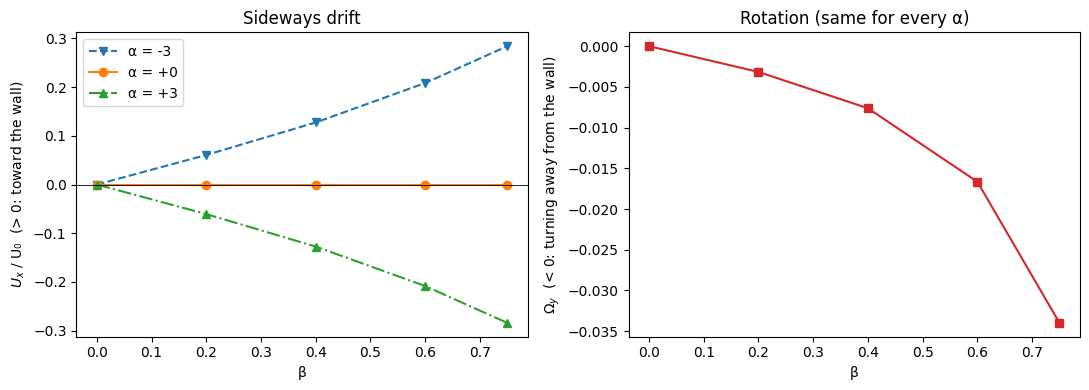

In [10]:
run("inputs/squirmer_kinematics.in", output_dir=f"{OUT}/offaxis",
    beta="0 0.2 0.4 0.6 0.75", n_theta=24, sphere_level=2, towed_drag=0)
k = load(f"{OUT}/offaxis/kinematics.csv")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for alpha, st in [(-3, "v--"), (0, "o-"), (3, "^-.")]:
    ax[0].plot(k["beta"], (k["UB1x"] + alpha * k["UB2x"]) / U0, st, label=f"α = {alpha:+d}")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set(xlabel="β", ylabel="$U_x$ / U₀  (> 0: toward the wall)", title="Sideways drift")
ax[0].legend()
ax[1].plot(k["beta"], k["OB1y"], "s-", color="C3")
ax[1].set(xlabel="β", ylabel="$Ω_y$  (< 0: turning away from the wall)",
          title="Rotation (same for every α)")
plt.tight_layout(); plt.show()

## Step 3: Trajectories

Knowing $\mathbf U$ and $\boldsymbol\Omega$ at every position and orientation, the swimmer's path follows from

$$ \frac{d\mathbf X}{dt} = \mathbf U(\mathbf X, \mathbf e), \qquad \frac{d\mathbf e}{dt} = \boldsymbol\Omega(\mathbf X, \mathbf e)\times\mathbf e . $$

Every time step requires one BEM solve. Two things keep this affordable:

1. **Moving frame.** The tube moves along with the swimmer, so the tube mesh never changes. Its part of the matrix (about 90 % of the unknowns) is factorised **once**. Each step only rebuilds the swimmer's couplings and solves a small reduced (Schur-complement) system.
2. **Adams–Bashforth 4** time stepping: one solve per step, fourth-order accurate. It needs three past steps, so the first three steps use RK4.

Here we run a short, coarse **neutral** squirmer that starts at $\beta = 0.7$, parallel to the axis. The prediction from Zhu et al. is that it crosses the axis and turns around at **exactly the same distance** on the other side (amplitude $A = 2b_I$). This takes about a minute.

In [11]:
print((REPO / "inputs/trajectory_neutral.in").read_text())

# ---------------------------------------------------------------------------
# Stage 3: trajectory of a squirmer in a tube   (alpha = B2/B1 = 0)
#   run:  ./build/squirmer_bem inputs/trajectory_neutral.in
# Long runs can be split: set budget_s (seconds); rerunning the same command
# resumes from the checkpoint file <output_dir>/<name>.ckpt.
# ---------------------------------------------------------------------------
mode       = trajectory
output_dir = outputs/trajectories
name       = neutral

alpha        = 0        # < 0 pusher, 0 neutral, > 0 puller
a_over_R     = 0.3
beta0        = 0.7       # initial offset from the axis / (R - a)
pitch0_deg   = 0         # initial tilt toward the radial direction
yaw0_deg     = 0         # initial tilt toward the azimuthal direction (3D paths)
dt           = 0.5       # time step (units a/B1)
t_max        = 150
n_theta      = 30
sphere_level = 2
L_over_R     = 4
beta_stop    = 0.95      # stop at (near) wall contact
budget_s     = 0         # 

$ inputs/trajectory_neutral.in output_dir=outputs/tutorial/traj dt=1.0 t_max=44 n_theta=24


finished: t = 44.00, beta = 0.498, z = 27.21  (53 solves, 52.4 s, 0.99 s/solve)
[52.4 s]


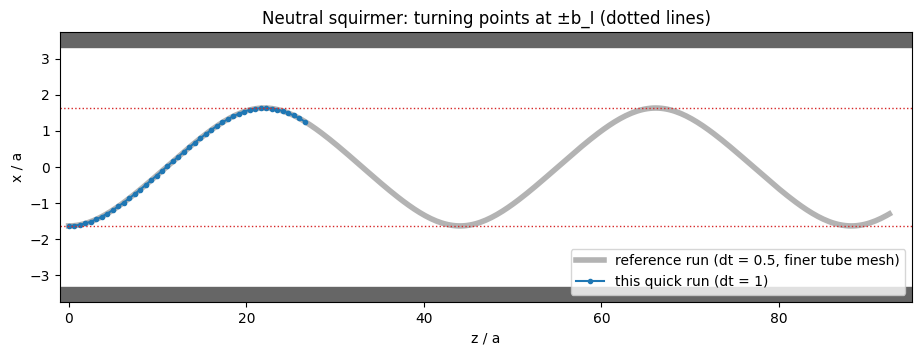

turning point reached: x_max / b_I = 0.9994


In [12]:
(REPO / OUT / "traj").mkdir(parents=True, exist_ok=True)
(REPO / OUT / "traj" / "neutral.ckpt").unlink(missing_ok=True)     # start fresh
run("inputs/trajectory_neutral.in", output_dir=f"{OUT}/traj", dt=1.0, t_max=44, n_theta=24)
d = load(f"{OUT}/traj/neutral.csv")
ref = load("outputs/reference/trajectories/neutral.csv")
b0 = 0.7 * (R - 1)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(ref["z"], ref["x"], "-", color="0.7", lw=4, label="reference run (dt = 0.5, finer tube mesh)")
ax.plot(d["z"], d["x"], "o-", ms=3, label="this quick run (dt = 1)")
for s in (1, -1):
    ax.axhline(s * b0, color="C3", ls=":", lw=1)
ax.axhspan(R, R + .4, color="0.4"); ax.axhspan(-R - .4, -R, color="0.4")
ax.set(xlabel="z / a", ylabel="x / a", xlim=(-1, 95), ylim=(-R - .4, R + .4),
       title="Neutral squirmer: turning points at ±b_I (dotted lines)")
ax.legend(loc="lower right"); plt.show()
print(f"turning point reached: x_max / b_I = {d['x'].max() / b0:.4f}")

The quick run follows the reference run closely, and it turns around at the starting distance to within a fraction of a percent.

### The four regimes

Long runs take about 2 s per step on one core, i.e. 5–10 minutes each. The repository ships these results in `outputs/reference/trajectories/`, produced with the `inputs/trajectory_*.in` files. To reproduce them:

```bash
./build/squirmer_bem inputs/trajectory_puller_a5.in
```

If a run has to be split into pieces, set `budget_s` (in seconds). Running the same command again resumes from the checkpoint file.

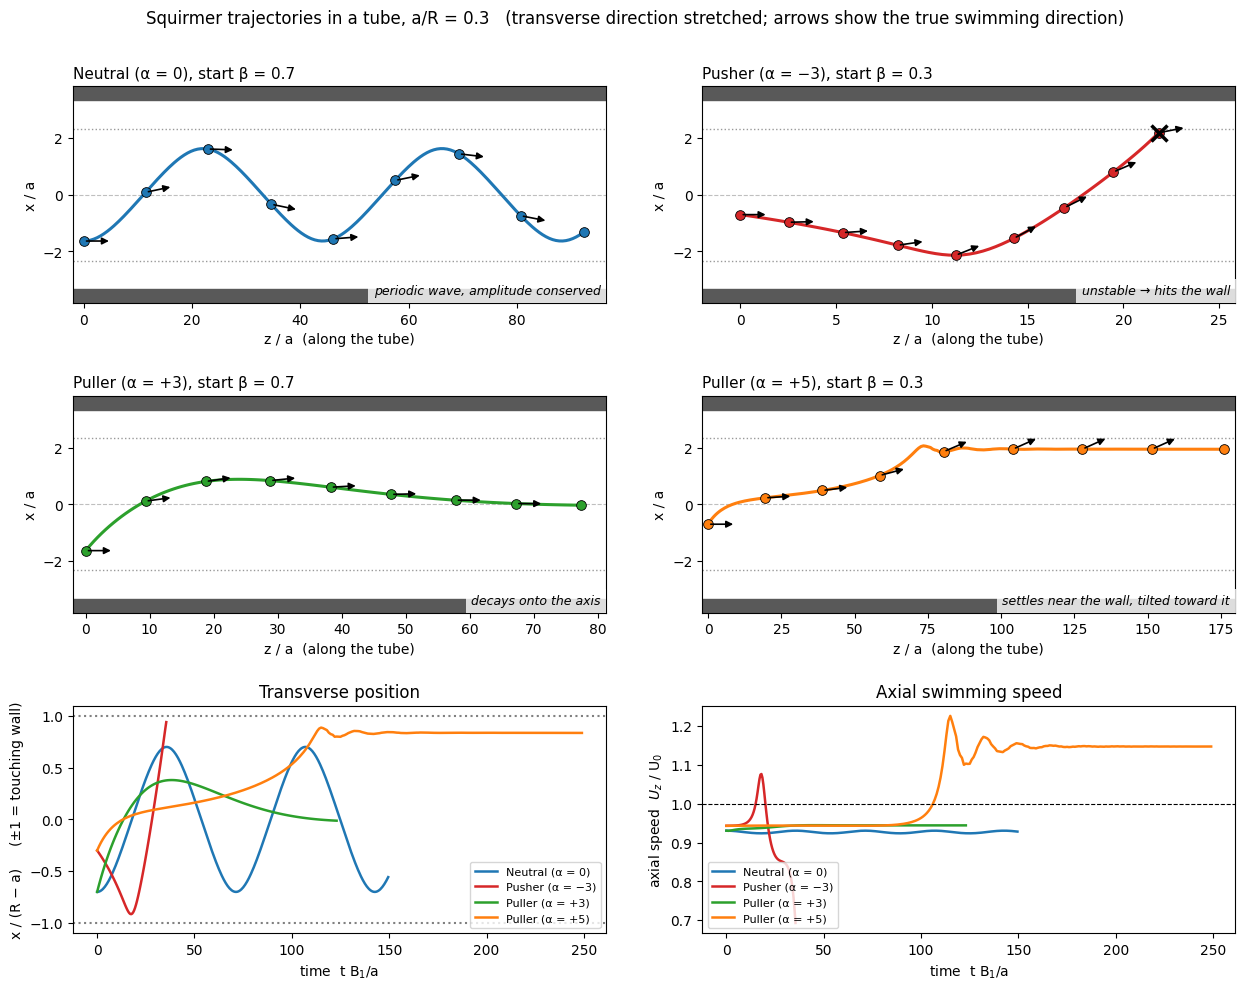

In [13]:
import plot_trajectories
fig = plot_trajectories.plot(str(REPO / "outputs/reference/trajectories"))
plt.show()

* **Neutral ($\alpha = 0$):** a periodic wave with exactly conserved amplitude. The wall's rotation effect makes the swimmer oscillate, but it never damps or grows.
* **Pusher ($\alpha = -3$):** the sideways drift toward the wall wins, and each swing overshoots further until the swimmer crashes into the wall.
* **Puller ($\alpha = +3$):** the drift away from the wall damps the oscillation, and the swimmer settles on the axis.
* **Strong puller ($\alpha = +5$):** above a critical $\alpha_c \approx 3.86$ (for $a/R = 0.3$) the axis becomes unstable. The swimmer settles on a straight path near the wall, tilted toward it by about 24°, and swims about 15 % **faster** than in free space.

## Running the tests

The `tests/` folder contains three self-checking programs. Each prints PASS/FAIL for every check and writes its data to `outputs/tests/`.

```bash
cd build && ctest --output-on-failure        # or:  make test
./build/test_squirmer --full                   # production meshes (~3 min)
./build/test_trajectory --full                 # the four long runs (~30 min)
python3 tests/plot_duct_flow.py                # figures from the test data
python3 tests/plot_squirmer.py
python3 tests/plot_trajectories.py outputs/tests/trajectories
```

## Exercises

1. **Confinement.** Rerun the on-axis kinematics for `a_over_R = 0.5 0.6`. How far does the drag deviate from Haberman–Sayre? Is it the solver or the formula? (Hint: refine `n_theta` and see whether the BEM value changes.)
2. **Critical α.** Run trajectories for $\alpha = 3.5, 4, 4.5$ starting near the axis. Where does the axis stop being stable?
3. **3D paths.** Set `yaw0_deg = 10` to give the swimmer an initial sideways tilt. Does the neutral squirmer still move in a plane?
4. **Tube length.** Change `L_over_R` from 4 to 6. How much do the results change?